# Analysis of QRC-ESN vs. Classical ESN Results

### **Notebook Objective**

This notebook analyzes the results generated by `01_run_experiments.ipynb`. Its purpose is to load the saved experimental data, identify the best-performing models, and visualize their performance without re-running any of the computationally expensive training processes.

### **Process**
1.  **Load Data**: Import the results from the `.csv` file.
2.  **Comparative Analysis**: Find the best hyperparameters for both QRC and Classical ESN models for each data profile based on the median Mean Squared Error (MSE).
3.  **Display Summaries**: Present the findings in clear, comparative tables.
4.  **Visualize**: (Placeholder) Generate plots to visually compare the performance of the best models on the time series data.

In [1]:
# === IMPORTS AND SETUP ===
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import our custom modules
from src.data_generation import mackey_glass, generate_arma_data, generate_narma_data
from src.visualization import (
    plot_best_model_comparison,
    plot_cv_split_overview,
    plot_cv_vs_test_scatter,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Jupyter magic command for automatic reloading of external modules
%load_ext autoreload
%autoreload 2

# Pandas display options for better table formatting
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

print("Libraries and modules loaded successfully.")

Libraries and modules loaded successfully.


In [2]:
# === LOAD RESULTS DATA ===

RESULTS_FILENAME = '../data/results_comparative.csv'

try:
    results_df = pd.read_csv(RESULTS_FILENAME)
    print(f"Successfully loaded {len(results_df)} results from '{RESULTS_FILENAME}'.")
except FileNotFoundError:
    print(f"ERROR: The results file '{RESULTS_FILENAME}' was not found.")
    print("Please run the '01_run_experiments.ipynb' notebook first to generate the results.")
    results_df = pd.DataFrame() # Create an empty DataFrame to prevent errors in subsequent cells

# Display a sample of the loaded data
if not results_df.empty:
    results_df.head()

Successfully loaded 1080 results from '../data/results_comparative.csv'.


In [3]:
# === COMPARATIVE ANALYSIS ===
# Hyperparameter selection is performed on sliding-window CV MSE (median_cv_mse).
# The reported performance comes from the held-out test set (median_test_mse).

comparison_summary = []

if not results_df.empty:
    for profile_name in results_df['data_profile'].unique():
        profile_df = results_df[results_df['data_profile'] == profile_name]

        qrc_df = profile_df[profile_df['model_type'] == 'QRC'].dropna(subset=['median_cv_mse'])
        classical_df = profile_df[profile_df['model_type'] == 'Classical_ESN'].dropna(subset=['median_cv_mse'])

        if qrc_df.empty or classical_df.empty:
            print(f"--> INFO: Skipping profile '{profile_name}' due to missing results for one or both models.")
            continue

        best_qrc_row = qrc_df.loc[qrc_df['median_cv_mse'].idxmin()]
        best_classical_row = classical_df.loc[classical_df['median_cv_mse'].idxmin()]

        summary = {
            'Data Profile': profile_name,
            'QRC CV MSE': best_qrc_row['median_cv_mse'],
            'QRC Test MSE': best_qrc_row['median_test_mse'],
            'Classical CV MSE': best_classical_row['median_cv_mse'],
            'Classical Test MSE': best_classical_row['median_test_mse'],
            'QRC Stability (CV test)': best_qrc_row['cv_test_mse'],
            'Classical Stability (CV test)': best_classical_row['cv_test_mse']
        }
        comparison_summary.append(summary)

if comparison_summary:
    summary_df = pd.DataFrame(comparison_summary)
    print("--- Best Model Comparison (selected by CV MSE, reported on test MSE) ---")
    print(summary_df.to_string(index=False))
else:
    print("\nNo valid results found to generate a comparison summary.")

--- Best Model Comparison (selected by CV MSE, reported on test MSE) ---
          Data Profile  QRC CV MSE  QRC Test MSE  Classical CV MSE  Classical Test MSE  QRC Stability (CV test)  Classical Stability (CV test)
 Mackey_Glass_(tau=17)    0.000004      0.000003      3.971798e-08        1.807135e-08                 2.892534                       0.145323
 Mackey_Glass_(tau=30)    0.000005      0.000003      7.135180e-08        6.346270e-08                 2.078701                       0.096052
Mackey_Glass_(tau=100)    0.000003      0.000007      8.685294e-08        3.001105e-07                 0.608976                       0.037698
   ARMA_1_2_stochastic    0.008070      0.007985      7.779523e-03        7.763014e-03                 0.011097                       0.008660
       NARMA10_Chaotic    0.009123      0.009046      8.400934e-03        8.234792e-03                 0.010000                       0.013725
        NARMA5_Chaotic    0.013452      0.012156      1.275676e-02   

In [4]:
# === DETAILED HYPERPARAMETERS OF BEST MODELS ===
# Best configuration per (profile, model) is chosen by lowest median_cv_mse.

if not results_df.empty:
    valid_results_df = results_df.dropna(subset=['median_cv_mse'])

    best_models_df = valid_results_df.loc[
        valid_results_df.groupby(['data_profile', 'model_type'])['median_cv_mse'].idxmin()
    ]

    if not best_models_df.empty:
        print("\n--- Detailed Hyperparameters of Best Models (by CV MSE) ---")
        print(best_models_df.sort_values(by=['data_profile', 'model_type']).to_string())
    else:
        print("Could not determine the best models.")


--- Detailed Hyperparameters of Best Models (by CV MSE) ---
        model_type            data_profile  median_cv_mse    std_cv_mse  cv_cv_mse  median_test_mse  std_test_mse  cv_test_mse  leakage_rate    lambda_reg  window_size  n_layers  lag  base_seed  reservoir_size  spectral_radius  sparsity
634  Classical_ESN     ARMA_1_2_stochastic   7.779523e-03  7.960893e-04   0.102331     7.763014e-03  6.722901e-05     0.008660           0.9  1.000000e-08           10       NaN  NaN       2025            50.0              0.9       0.1
553            QRC     ARMA_1_2_stochastic   8.070291e-03  9.137675e-04   0.113226     7.984800e-03  8.860762e-05     0.011097           0.1  1.000000e-08            8       2.0  0.0       2025             NaN              NaN       NaN
519  Classical_ESN  Mackey_Glass_(tau=100)   8.685294e-08  2.373932e-08   0.273328     3.001105e-07  1.131354e-08     0.037698           0.9  1.000000e-08           10       NaN  NaN       2025           150.0              0.9  


--- Generating plot for profile: Mackey_Glass_(tau=17) ---

Retraining best QRC model on full CV pool...
Best QRC Median Test MSE: 0.000003
Retraining best Classical ESN on full CV pool...
Best Classical ESN Median Test MSE: 0.000000


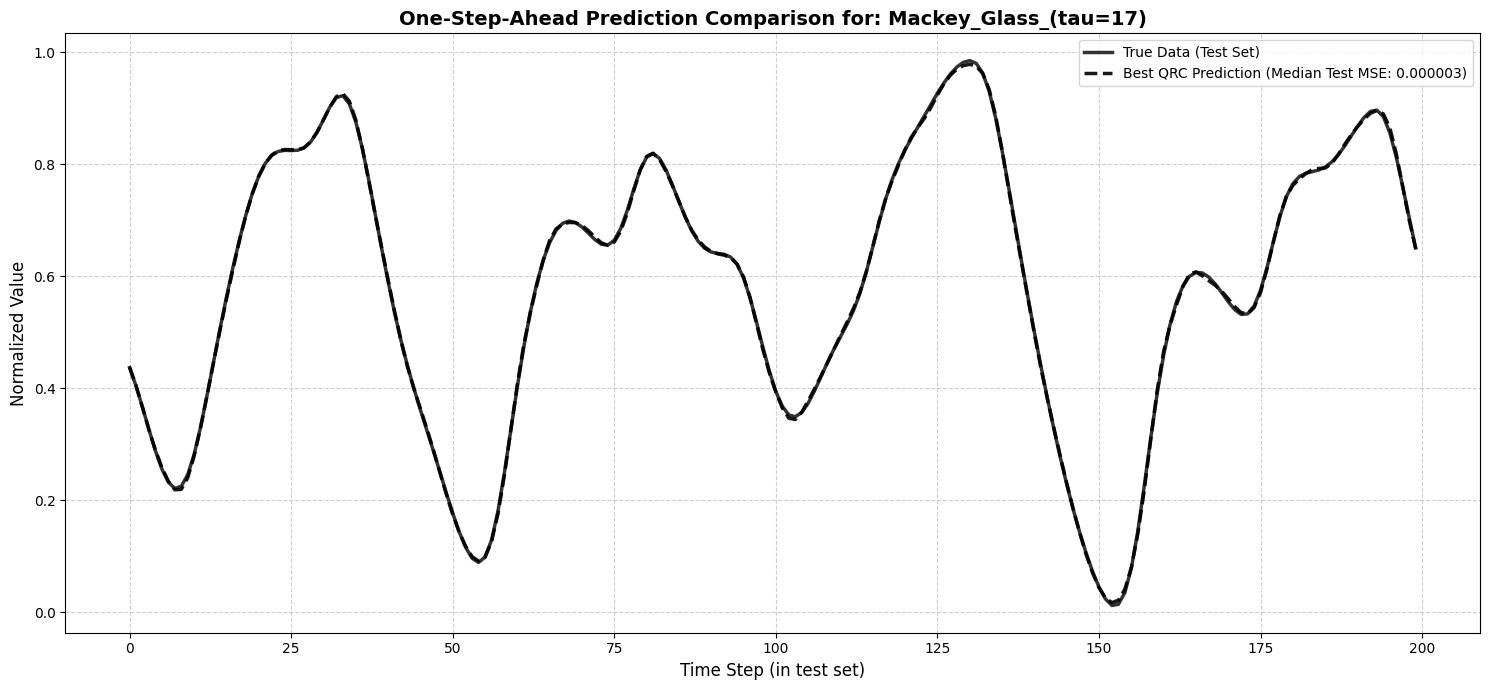


--- Generating plot for profile: Mackey_Glass_(tau=30) ---

Retraining best QRC model on full CV pool...
Best QRC Median Test MSE: 0.000003
Retraining best Classical ESN on full CV pool...
Best Classical ESN Median Test MSE: 0.000000


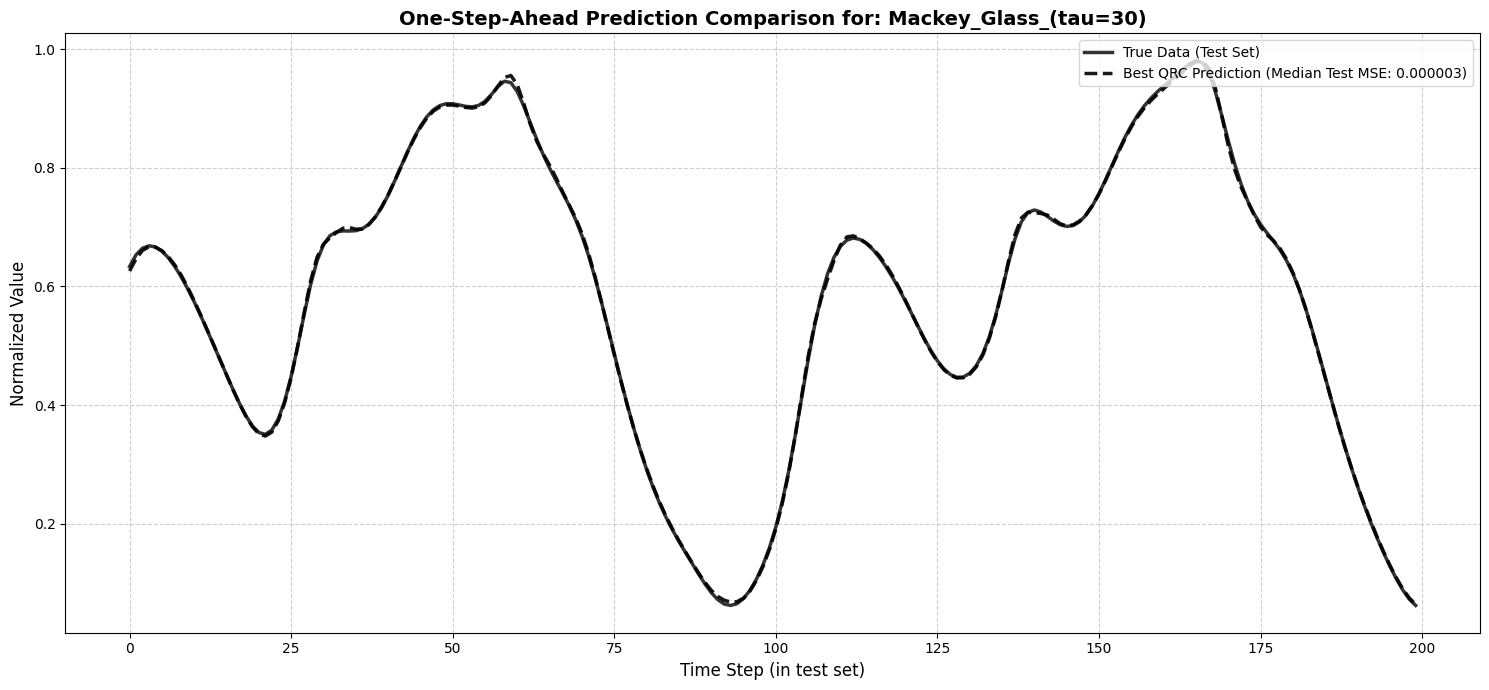


--- Generating plot for profile: Mackey_Glass_(tau=100) ---

Retraining best QRC model on full CV pool...
Best QRC Median Test MSE: 0.000007
Retraining best Classical ESN on full CV pool...
Best Classical ESN Median Test MSE: 0.000000


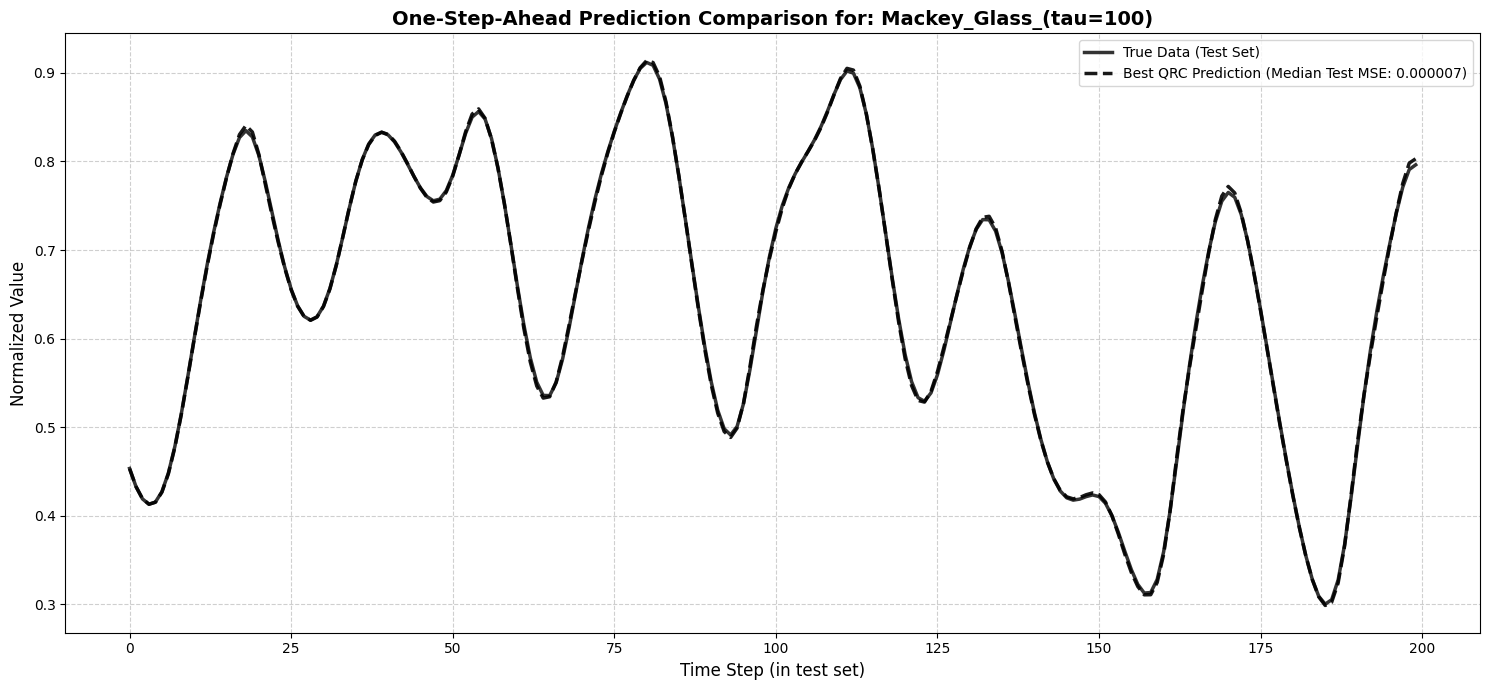


--- Generating plot for profile: ARMA_1_2_stochastic ---

Retraining best QRC model on full CV pool...
Best QRC Median Test MSE: 0.007985
Retraining best Classical ESN on full CV pool...
Best Classical ESN Median Test MSE: 0.007763


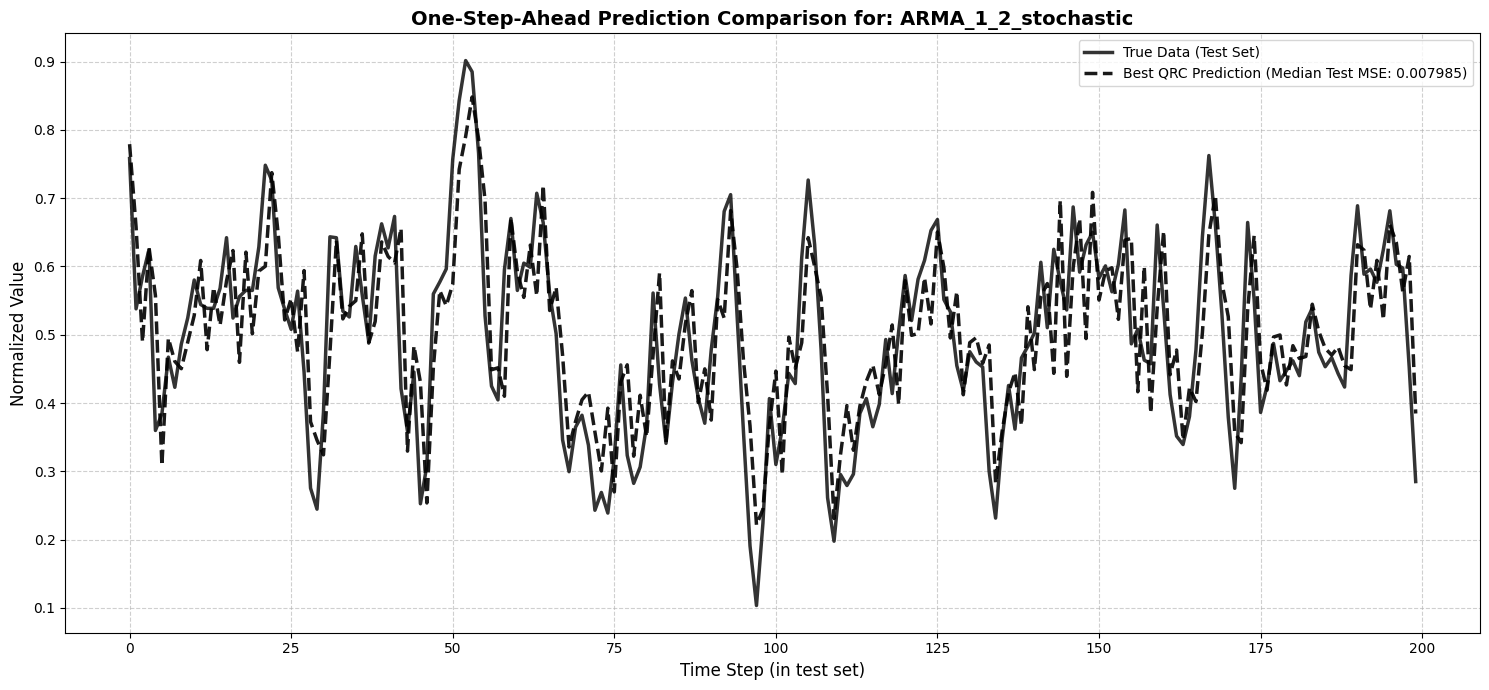


--- Generating plot for profile: NARMA10_Chaotic ---

Retraining best QRC model on full CV pool...
Best QRC Median Test MSE: 0.009046
Retraining best Classical ESN on full CV pool...
Best Classical ESN Median Test MSE: 0.008235


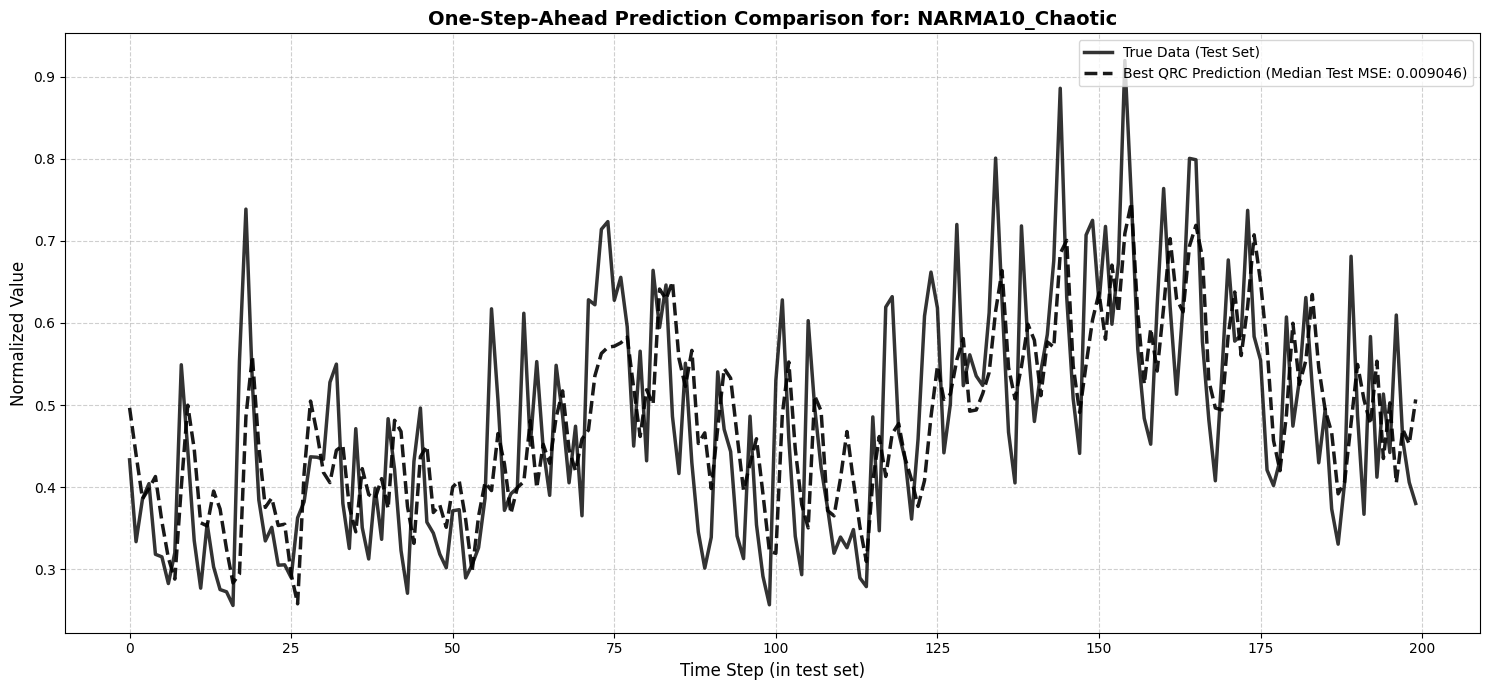


--- Generating plot for profile: NARMA5_Chaotic ---

Retraining best QRC model on full CV pool...
Best QRC Median Test MSE: 0.012156
Retraining best Classical ESN on full CV pool...
Best Classical ESN Median Test MSE: 0.011424


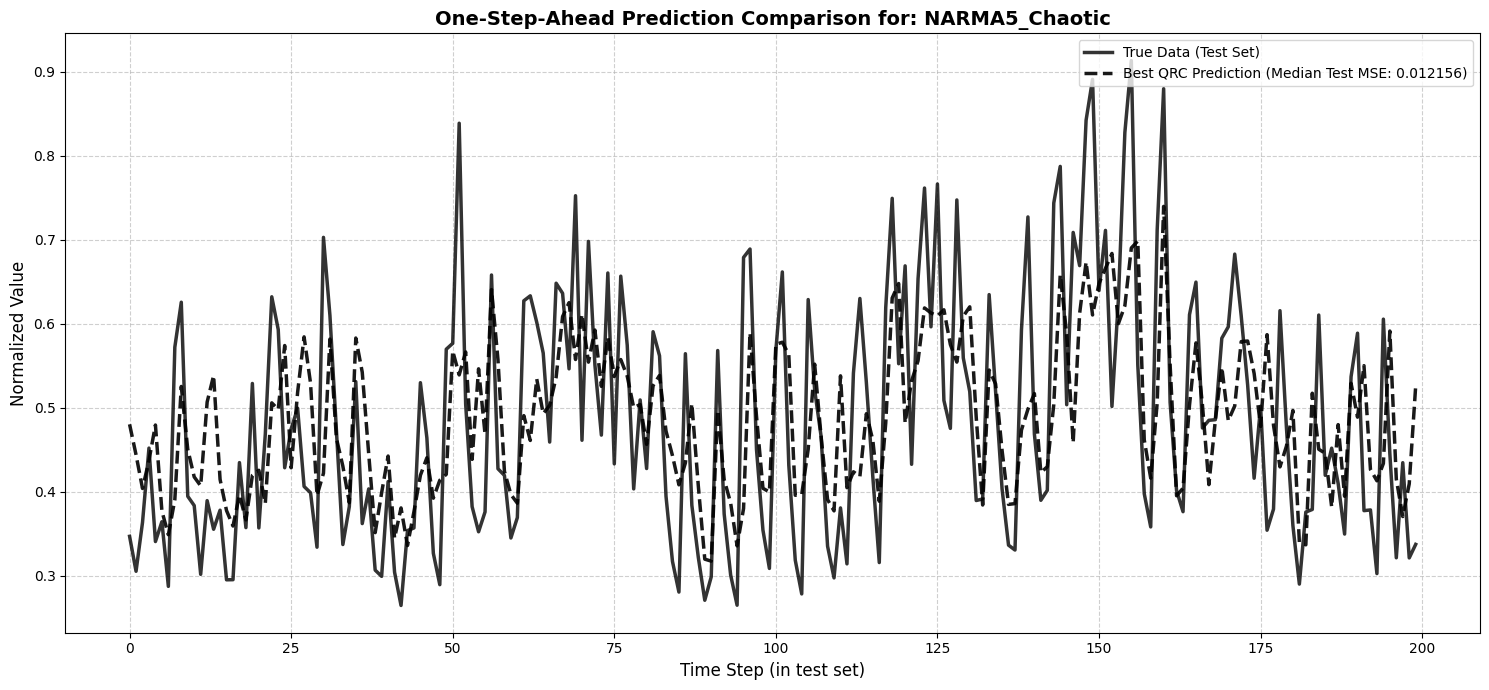

In [5]:
# === VISUALIZE BEST MODEL PERFORMANCE ===

# This cell iterates through each data profile, finds the best performing
# models (by CV MSE), and uses the dedicated plotting function from
# src/visualization.py to generate and display a comparative plot.

# Define constants needed for data regeneration
constants = {
    'TRAIN_FRACTION': 0.8,
    'N_SPLITS': 5,
    'WASHOUT': 100,
    'SEED': 2025
}

# Define the data profiles again so the visualization module can access them
# This should match the configuration in the experiment runner notebook
data_profiles_config = [
    {'name': 'Mackey_Glass_(tau=17)', 'generator': mackey_glass, 'params': {'tau': 17}},
    {'name': 'Mackey_Glass_(tau=30)', 'generator': mackey_glass, 'params': {'tau': 30}},
    {'name': 'Mackey_Glass_(tau=100)', 'generator': mackey_glass, 'params': {'tau': 100}},
    {'name': 'ARMA_1_2_stochastic', 'generator': generate_arma_data, 'params': {}},
    {'name': 'NARMA10_Chaotic', 'generator': generate_narma_data, 'params': {'order': 10}},
    {'name': 'NARMA5_Chaotic', 'generator': generate_narma_data, 'params': {'order': 5}}
]


if not results_df.empty:
    for profile_config in data_profiles_config:
        profile_name = profile_config['name']

        # Filter results for the current profile
        profile_df = results_df[results_df['data_profile'] == profile_name]

        # Selection is done on CV MSE
        qrc_df = profile_df[profile_df['model_type'] == 'QRC'].dropna(subset=['median_cv_mse'])
        classical_df = profile_df[profile_df['model_type'] == 'Classical_ESN'].dropna(subset=['median_cv_mse'])

        if qrc_df.empty or classical_df.empty:
            print(f"\n--> SKIPPING PLOT for '{profile_name}' due to missing results.")
            continue

        best_qrc_row = qrc_df.loc[qrc_df['median_cv_mse'].idxmin()]
        best_classical_row = classical_df.loc[classical_df['median_cv_mse'].idxmin()]

        # Existing one-step-ahead comparison plot (test set)
        plot_best_model_comparison(best_qrc_row, best_classical_row, profile_config, constants)
else:
    print("Results DataFrame is empty. Cannot generate plots.")


--- Generating CV split overview for profile: Mackey_Glass_(tau=17) ---



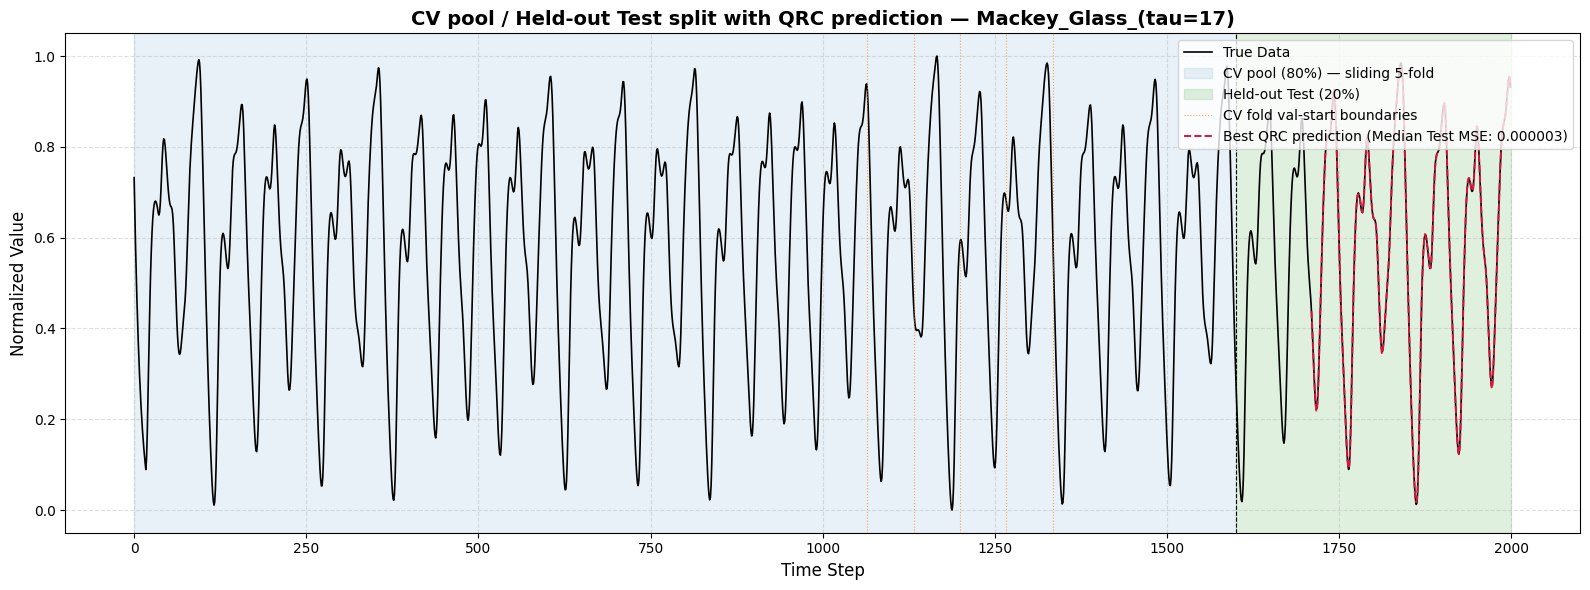


--- Generating CV split overview for profile: Mackey_Glass_(tau=30) ---



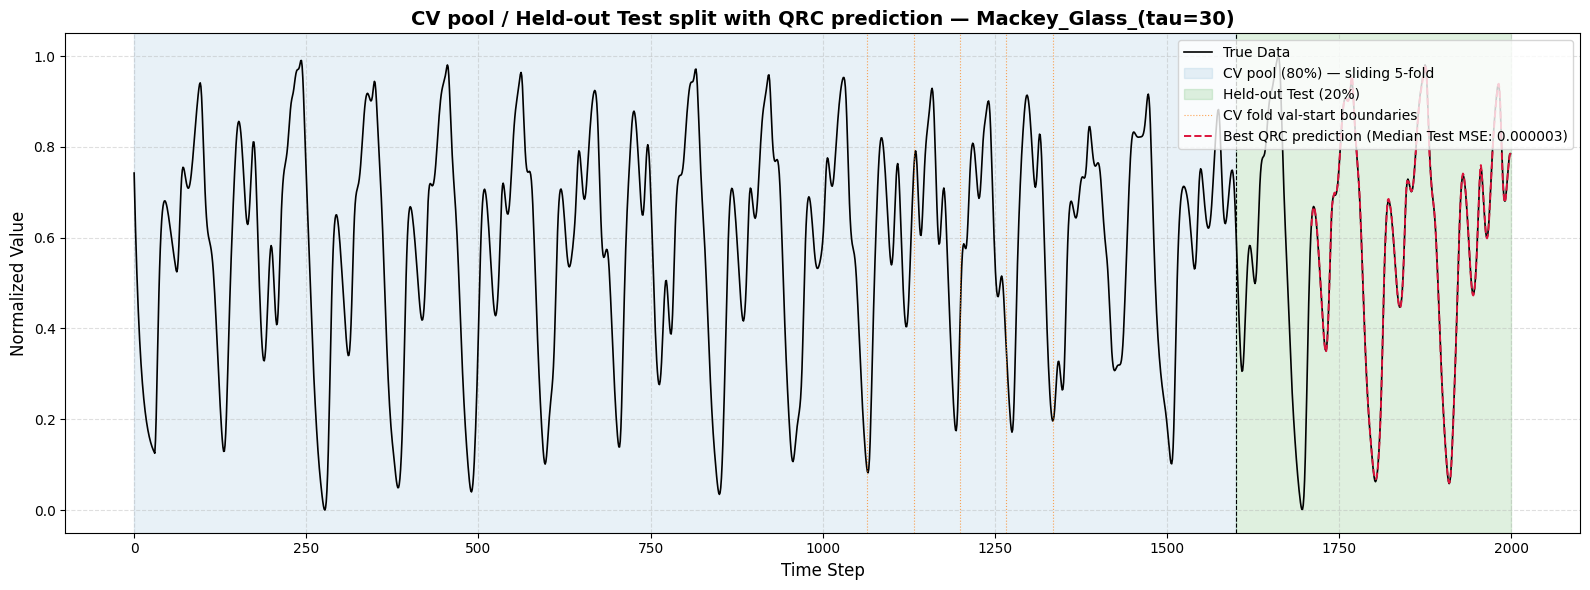


--- Generating CV split overview for profile: Mackey_Glass_(tau=100) ---



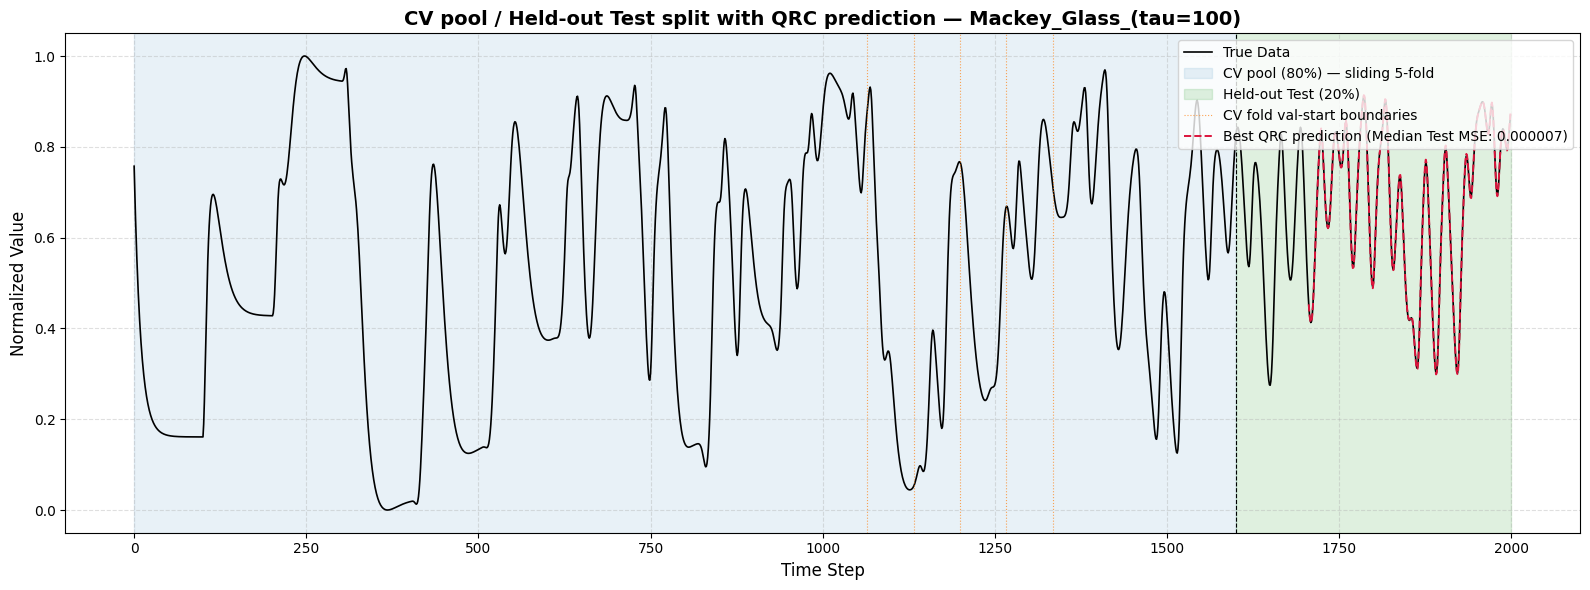


--- Generating CV split overview for profile: ARMA_1_2_stochastic ---



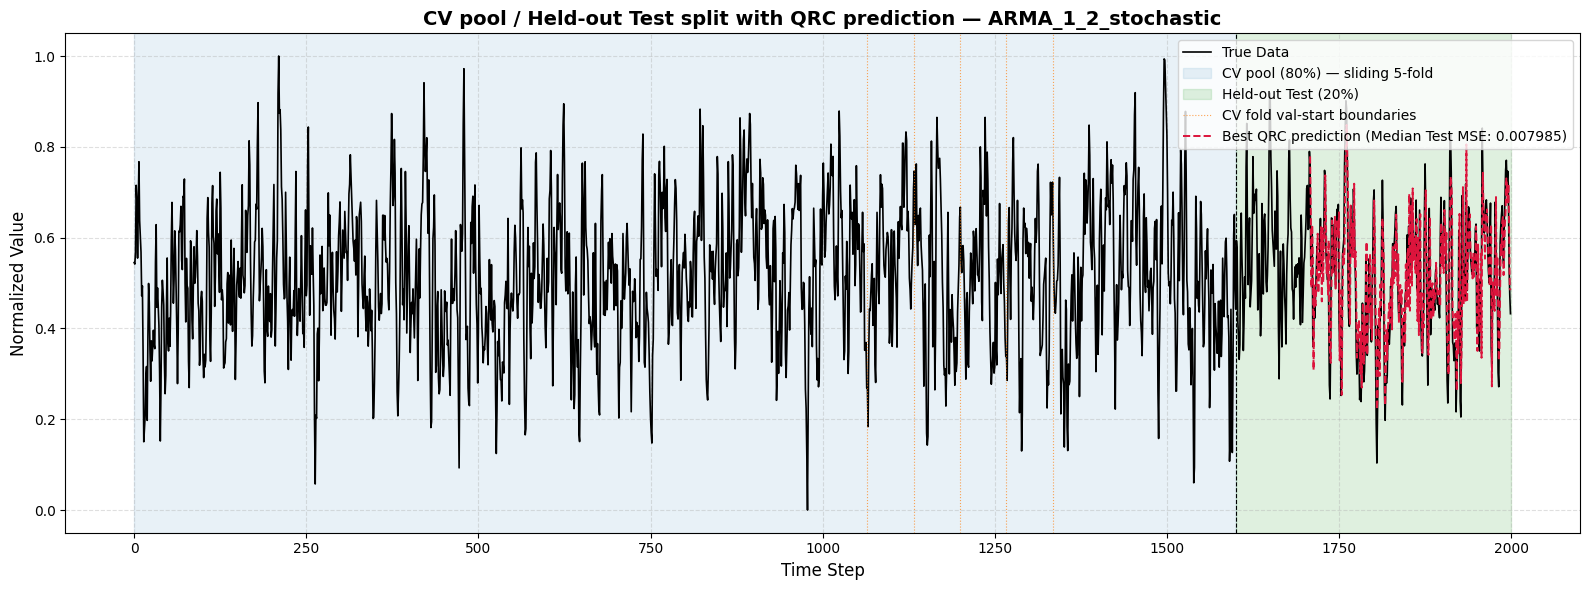


--- Generating CV split overview for profile: NARMA10_Chaotic ---



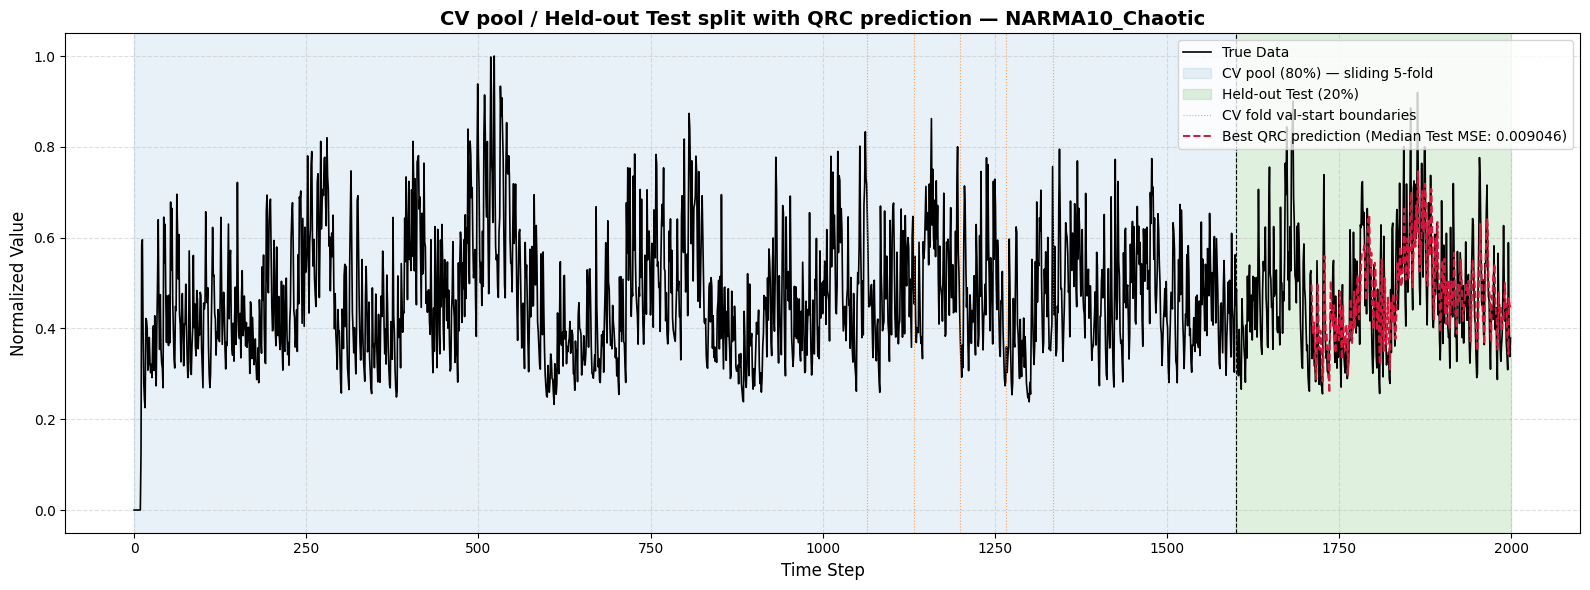


--- Generating CV split overview for profile: NARMA5_Chaotic ---



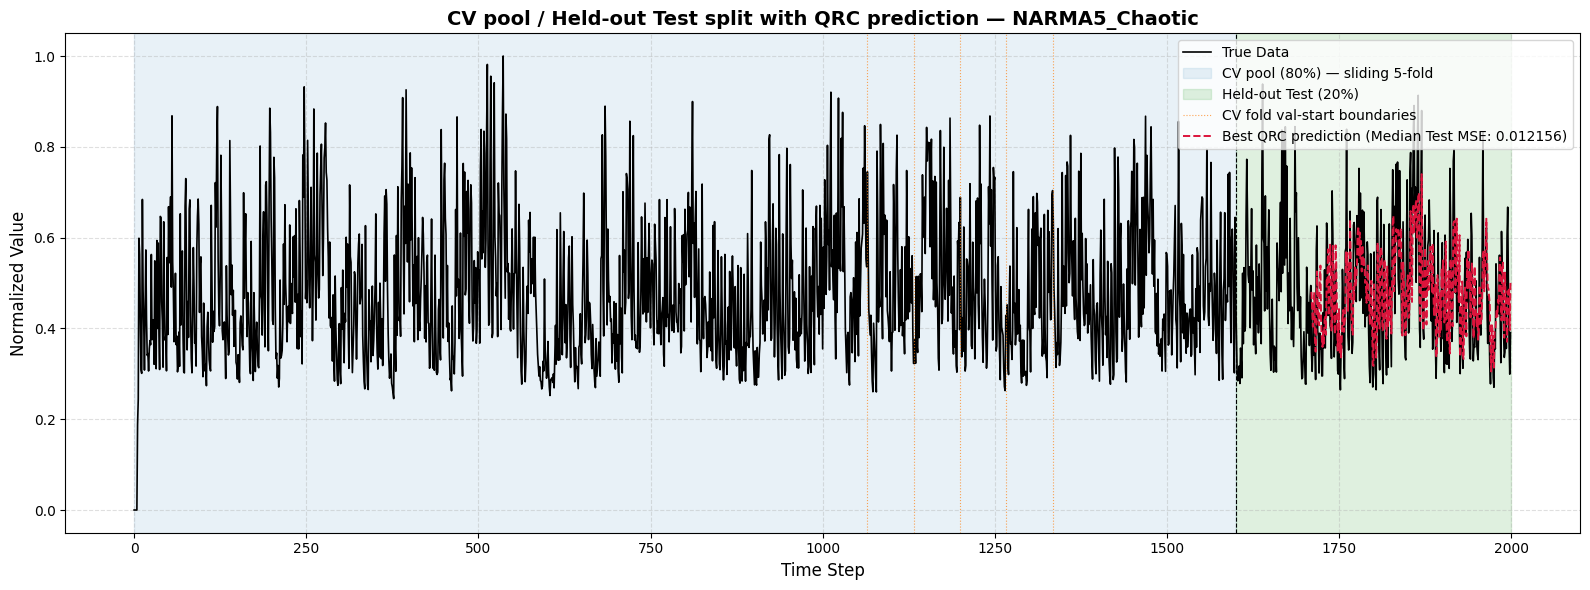

In [6]:
# === CV SPLIT OVERVIEW PLOTS ===
# Visualization: full time series with CV pool (80%) and held-out test (20%)
# regions shaded. Sliding-window CV fold val-boundaries are marked inside
# the CV pool, and the best QRC prediction is overlaid on the test segment.

if not results_df.empty:
    for profile_config in data_profiles_config:
        profile_name = profile_config['name']

        profile_df = results_df[results_df['data_profile'] == profile_name]
        qrc_df = profile_df[profile_df['model_type'] == 'QRC'].dropna(subset=['median_cv_mse'])

        if qrc_df.empty:
            print(f"\n--> SKIPPING OVERVIEW for '{profile_name}' due to missing QRC results.")
            continue

        best_qrc_row = qrc_df.loc[qrc_df['median_cv_mse'].idxmin()]
        plot_cv_split_overview(best_qrc_row, profile_config, constants)
else:
    print("Results DataFrame is empty. Cannot generate overview plots.")

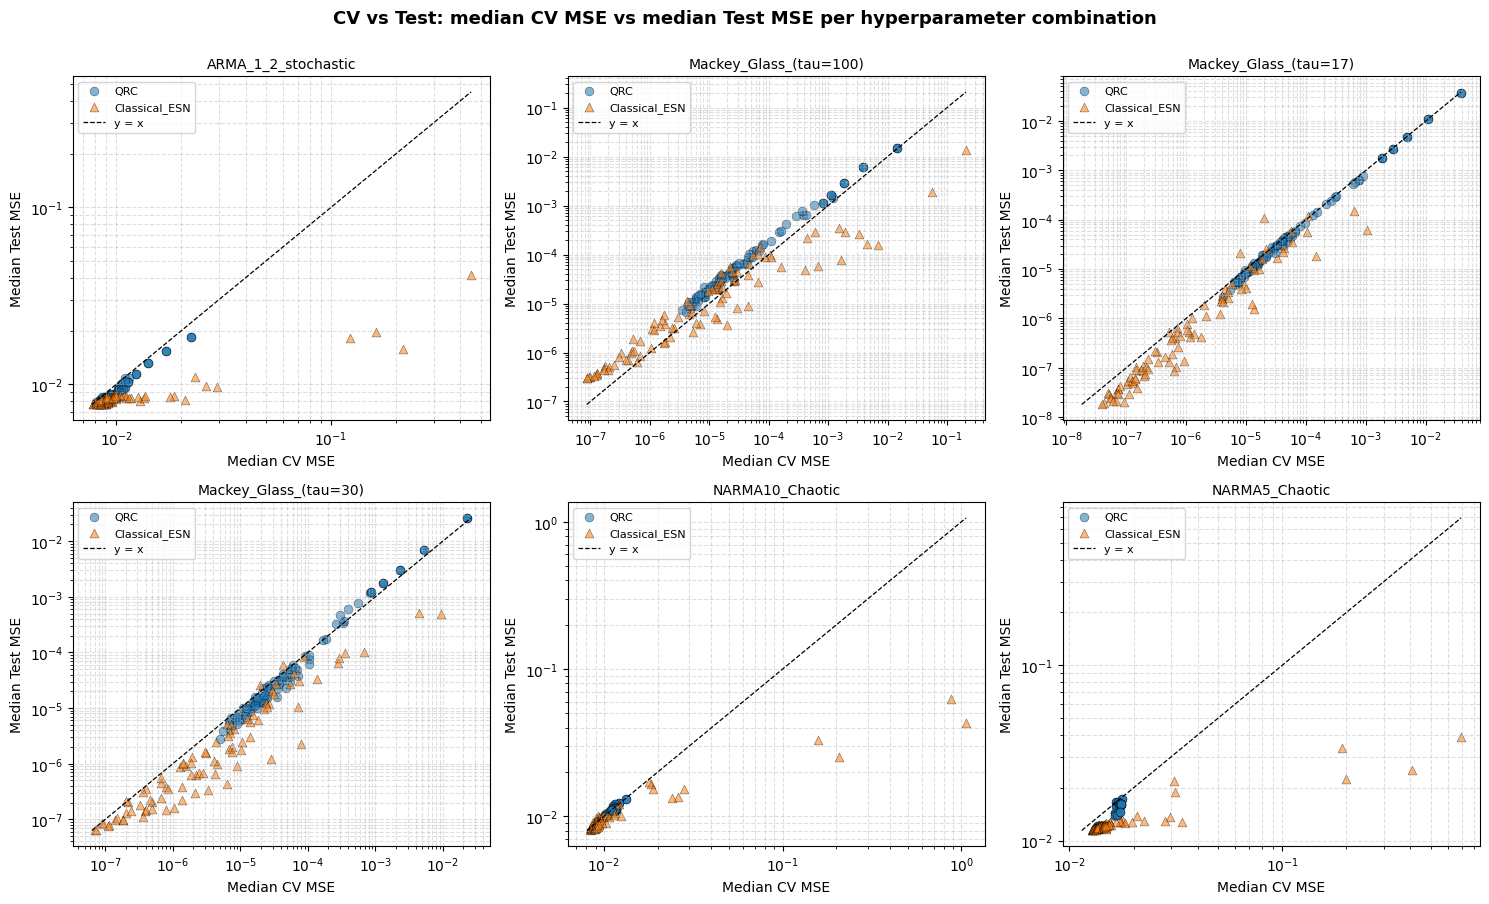

In [7]:
# === CV vs TEST SCATTER ("CV is honest") ===
# For every hyperparameter combination we have BOTH the K-fold sliding-window
# CV MSE and the held-out test MSE (Variant B). Plotting them against each
# other reveals whether CV selection is consistent with test performance:
# points close to the y=x line indicate honest CV. Systematic deviation would
# suggest the CV estimate is biased.

if not results_df.empty:
    plot_cv_vs_test_scatter(results_df)
else:
    print("Results DataFrame is empty. Cannot generate CV-vs-Test scatter.")